In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


____
# Colocalization definition
- select the nearest in time of a SWOT image drifter point 
- import SWOT data at this point :
    - for SWOT-250m interpolate on a cartesian grid, compute gradient on this grid, interpolate at the drifter position
    - for SWOT-2km compute gradient, interpolate at the drifter position
    - for SWOT-nadir, select nearest nadir point, comute gradient at this point

_______
# Data

In [2]:
drifters_sources = 'all_med_variational_10min_v0.nc'
df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_64247/137581442.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))


In [3]:
df.longitude

0         4.811970
1         4.812432
2         4.812916
3         4.813418
4         4.813933
            ...   
383258    2.417785
383259    2.416881
383260    2.415948
383261    2.414994
383262    2.414025
Name: longitude, Length: 383263, dtype: float64

In [4]:
era = xr.open_dataset('/Users/mdemol/DATA_WIND/era5.nc')
era

<xarray.Dataset> Size: 414MB
Dimensions:    (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude  (longitude) float32 244B 0.0 0.25 0.5 0.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 44.0 43.75 43.5 43.25 ... 36.5 36.25 36.0
  * time       (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23:00:00
Data variables:
    u10        (time, latitude, longitude) float64 59MB ...
    v10        (time, latitude, longitude) float64 59MB ...
    ewss       (time, latitude, longitude) float64 59MB ...
    msl        (time, latitude, longitude) float64 59MB ...
    nsss       (time, latitude, longitude) float64 59MB ...
    ust        (time, latitude, longitude) float64 59MB ...
    vst        (time, latitude, longitude) float64 59MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-09 13:21:39 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

__________
# era5

In [5]:
def cst_rio_z0(df):
    
    theta0 = - 22.5 * np.pi / 180 * np.sign(df.f)
    beta0 = 0.6
    
    uek_e = beta0 * (np.cos(theta0) * df.taue - np.sin(theta0) * df.taun)
    uek_n = beta0 * (np.sin(theta0) * df.taue + np.cos(theta0) * df.taun)
    df['winde0'] = df.f * uek_n
    df['windn0'] = -df.f * uek_e

def cst_rio_z15(df):
    
    theta15 = - 37.5 * np.pi / 180 * np.sign(df.f)#adapted for mediterranean sea
    beta15 = 0.15
    
    uek_e = beta15 * (np.cos(theta15) * df.taue - np.sin(theta15) * df.taun)
    uek_n = beta15 * (np.sin(theta15) * df.taue + np.cos(theta15) * df.taun)
    df['winde15'] = df.f * uek_n
    df['windn15'] = -df.f * uek_e

In [6]:
lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = era.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']
df0['f'] = 2 * 2 * np.pi / 86164.1 * np.sin(df0.latitude * np.pi / 180)
#df0 = df0.rename(columns = {'ewss':'taue', 'nsss':'taun'})
# Integrated stress -> mean stress
int_time = 1*3600
df0['taue'] = df0['ewss']/int_time
df0['taun'] = df0['nsss']/int_time
cst_rio_z0(df0)
cst_rio_z15(df0)
df0.to_csv(os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv'))

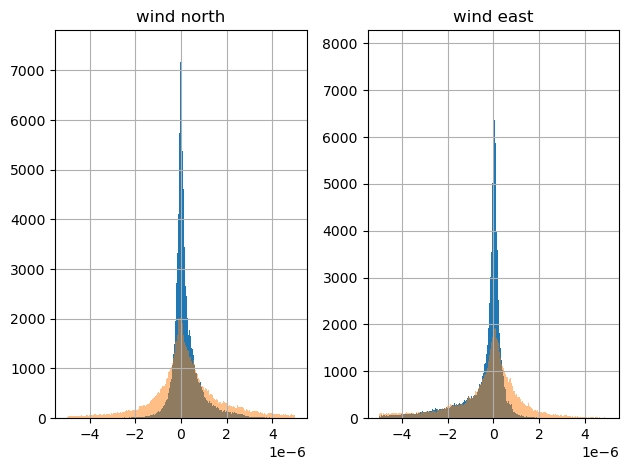

In [7]:
fig, axs = plt.subplots(1,2)
ax=axs[0]
bins = np.arange(-5e-6, 5e-6, 1e-8)
df0.windn15.hist(bins =bins, ax=ax, label = '15m')
df0.windn0.hist(bins =bins, ax=ax, alpha=0.5, label='surface')
ax.set_title('wind north')
ax=axs[1]
df0.winde15.hist(bins =bins, ax=ax, label = '15m')
df0.winde0.hist(bins =bins, ax=ax, alpha=0.5, label='surface')
ax.set_title('wind east')
fig.tight_layout()

In [87]:
df0.windn_15.mean(), df0.windn_15.std()

(0.0007733124735551095, 0.002530153038728046)

In [88]:
abs(df0.windn_15).median()

0.0007267316754991909

In [89]:
abs(df0.winde_15).median()

0.0008153950050409709